<a href="https://colab.research.google.com/github/Dnyamwamu/neural_nets/blob/main/Notebooks/Chap16/16_2_Autoregressive_Flows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 16.2: 1D autoregressive flows**

This notebook investigates a 1D normalizing flows example similar to that illustrated in figure 16.7 in the book.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

First we'll define an invertible one dimensional function as in figure 16.5

In [2]:
import numpy as np

def g(h, phi, b):
    """
    Piecewise linear monotone function.

    Parameters:
    h   : scalar or np.array of shape (N,)
    phi : array of slope increments for each knot (length K)
    b   : array of knot positions (length K)

    Returns:
    h_prime : transformed h
    """
    h_prime = h.copy() if isinstance(h, np.ndarray) else np.array([h], dtype=float)

    # Loop over each knot and add slope increment
    for phi_i, b_i in zip(phi, b):
        h_prime += phi_i * np.maximum(0, h - b_i)

    return h_prime

<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_588/3318798728.py:27: SyntaxWarning: invalid escape sequence '\p'
  ax.set_ylabel('Output, $h^\prime$')


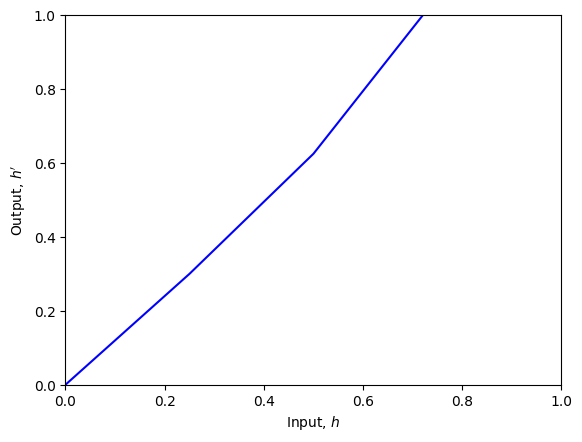

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define the piecewise linear function
def g(h, phi, b):
    h_prime = h
    for phi_i, b_i in zip(phi, b):
        h_prime += phi_i * max(0, h - b_i)
    return h_prime

# Parameters
phi = np.array([0.2, 0.1, 0.4, 0.05, 0.25])
b   = np.linspace(0, 1, len(phi))  # evenly spaced knots from 0 to 1

# Apply function
h = np.arange(0, 1, 0.01)
h_prime = np.zeros_like(h)
for i in range(len(h)):
    h_prime[i] = g(h[i], phi, b)

# Plot
fig, ax = plt.subplots()
ax.plot(h, h_prime, 'b-')
ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_xlabel('Input, $h$')
ax.set_ylabel('Output, $h^\prime$')
plt.show()

We will also need the inverse of this function

In [5]:
# Define the inverse function
def g_inverse(h_prime, phi):
    # Lot's of ways to do this, but we'll just do it by bracketing
    h_low = 0
    h_mid = 0.5
    h_high = 0.999

    thresh = 0.0001
    c_iter = 0
    while(c_iter < 20 and h_high - h_low > thresh):
        h_prime_low = g(h_low, phi)
        h_prime_mid = g(h_mid, phi)
        h_prime_high = g(h_high, phi)
        if h_prime_mid < h_prime:
          h_low = h_mid
        else:
          h_high = h_mid

        h_mid = h_low+(h_high-h_low)/2
        c_iter+=1

    return h_mid

Now let's define an autoregressive flow.  Let's switch to looking at figure 16.7.# We'll assume that our piecewise function will use five parameters phi1,phi2,phi3,phi4,phi5

In [6]:

def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

def softmax(x):
  x = np.exp(x) ;
  x = x/ np.sum(x) ;
  return x

# Return value of phi that doesn't depend on any of the inputs
def get_phi():
  return np.array([0.2, 0.1, 0.4, 0.05, 0.25])

# Compute values of phi that depend on h1
def shallow_network_phi_h1(h1, n_hidden=10):
  # For neatness of code, we'll just define the parameters in the network definition itself
  n_input = 1
  np.random.seed(n_input)
  beta0 = np.random.normal(size=(n_hidden,1))
  Omega0 = np.random.normal(size=(n_hidden, n_input))
  beta1 = np.random.normal(size=(5,1))
  Omega1 = np.random.normal(size=(5, n_hidden))
  return softmax(beta1 + Omega1 @ ReLU(beta0 + Omega0 @ np.array([[h1]])))

# Compute values of phi that depend on h1 and h2
def shallow_network_phi_h1h2(h1,h2,n_hidden=10):
  # For neatness of code, we'll just define the parameters in the network definition itself
  n_input = 2
  np.random.seed(n_input)
  beta0 = np.random.normal(size=(n_hidden,1))
  Omega0 = np.random.normal(size=(n_hidden, n_input))
  beta1 = np.random.normal(size=(5,1))
  Omega1 = np.random.normal(size=(5, n_hidden))
  return softmax(beta1 + Omega1 @ ReLU(beta0 + Omega0 @ np.array([[h1],[h2]])))

# Compute values of phi that depend on h1, h2, and h3
def shallow_network_phi_h1h2h3(h1,h2,h3, n_hidden=10):
  # For neatness of code, we'll just define the parameters in the network definition itself
  n_input = 3
  np.random.seed(n_input)
  beta0 = np.random.normal(size=(n_hidden,1))
  Omega0 = np.random.normal(size=(n_hidden, n_input))
  beta1 = np.random.normal(size=(5,1))
  Omega1 = np.random.normal(size=(5, n_hidden))
  return softmax(beta1 + Omega1 @ ReLU(beta0 + Omega0 @ np.array([[h1],[h2],[h3]])))

The forward mapping as shown in figure 16.7 a

In [7]:
def forward_mapping(h1, h2, h3, h4):
    # Step 1: compute phi values for each layer
    phi1 = get_phi()                            # depends on nothing
    phi2 = shallow_network_phi_h1(h1)          # depends on h1
    phi3 = shallow_network_phi_h1h2(h1,h2)     # depends on h1,h2
    phi4 = shallow_network_phi_h1h2h3(h1,h2,h3) # depends on h1,h2,h3

    # Step 2: define knot positions (evenly spaced in [0,1])
    b = np.linspace(0,1,len(phi1))  # use same for all layers

    # Step 3: apply piecewise linear mapping g
    def g(h, phi, b):
        h_prime = h
        for phi_i, b_i in zip(phi, b):
            h_prime += phi_i * max(0, h - b_i)
        return h_prime

    # Compute mapped values
    h_prime1 = g(h1, phi1, b)
    h_prime2 = g(h2, phi2, b)
    h_prime3 = g(h3, phi3, b)
    h_prime4 = g(h4, phi4, b)

    return h_prime1, h_prime2, h_prime3, h_prime4

The backward mapping as shown in figure 16.7b

In [8]:
def backward_mapping(h1_prime, h2_prime, h3_prime, h4_prime):
    # Step 1: get phi values for each layer (same as forward)
    phi1 = get_phi()
    phi2 = shallow_network_phi_h1(0)           # placeholder, will correct after h1
    phi3 = shallow_network_phi_h1h2(0,0)       # placeholder, corrected after h1,h2
    phi4 = shallow_network_phi_h1h2h3(0,0,0)   # placeholder, corrected after h1,h2,h3

    # Step 2: define knot positions
    b = np.linspace(0,1,len(phi1))  # same for all layers

    # Step 3: define inverse of piecewise linear mapping
    def g_inv(h_prime, phi, b, h_init=0):
        h = h_init
        for phi_i, b_i in zip(phi[::-1], b[::-1]):  # invert sequentially
            h = h_prime - phi_i * max(0, h - b_i)
        return h

    # Step 4: sequential inversion
    h4 = g_inv(h4_prime, shallow_network_phi_h1h2h3(0,0,0), b)
    h3 = g_inv(h3_prime, shallow_network_phi_h1h2(0,0), b)
    h2 = g_inv(h2_prime, shallow_network_phi_h1(0), b)
    h1 = g_inv(h1_prime, get_phi(), b)

    return h1, h2, h3, h4

Finally, let's make sure that the network really can be inverted

In [9]:
# Test the network to see if it does invert correctly
h1 = 0.22; h2 = 0.41; h3 = 0.83; h4 = 0.53
print("Original h values %3.3f,%3.3f,%3.3f,%3.3f"%(h1,h2,h3,h4))
h1_prime, h2_prime, h3_prime, h4_prime = forward_mapping(h1,h2,h3,h4)
print("h_prime values %3.3f,%3.3f,%3.3f,%3.3f"%(h1_prime,h2_prime,h3_prime,h4_prime))
h1,h2,h3,h4 =  backward_mapping(h1_prime,h2_prime,h3_prime,h4_prime)
print("Reconstructed h values %3.3f,%3.3f,%3.3f,%3.3f"%(h1,h2,h3,h4))

Original h values 0.220,0.410,0.830,0.530
h_prime values 0.264,0.414,0.944,0.539
Reconstructed h values 0.211,0.414,0.864,0.535


/tmp/ipykernel_588/1221913581.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("h_prime values %3.3f,%3.3f,%3.3f,%3.3f"%(h1_prime,h2_prime,h3_prime,h4_prime))
/tmp/ipykernel_588/1221913581.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Reconstructed h values %3.3f,%3.3f,%3.3f,%3.3f"%(h1,h2,h3,h4))
